# Fundación YPF - Data Science

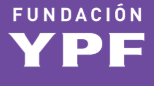

# Notebook 13: práctica integradora de transformación de datos

**Módulo III. Análisis exploratorio y transformación de datos.**

En esta notebook cerramos el módulo III. La idea es integrar en un solo flujo de trabajo todo lo que fuimos viendo por partes en las notebooks 8 a 12: describir los datos, tratar valores faltantes, filtrar outliers, generar variables nuevas, codificar categóricas y dejar las variables en una escala razonable para modelar.

## Cómo está organizada

1. **Parte A. Repaso guiado en la sala general.** Recorremos el flujo completo sobre el dataset de expectativa de vida. La docente explica y ejecuta, ustedes siguen y preguntan.
2. **Parte B. Ejercicios en salas de Zoom.** Aplican el mismo flujo sobre un dataset nuevo y bastante sucio: publicaciones de venta de autos usados. Tienen 50 minutos.
3. **Parte C. Puesta en común.** Volvemos a la sala general, revisamos los ejercicios y armamos el checklist de un dataset listo para machine learning.
4. **Anexo. Soluciones sugeridas** de la parte B, para consultar después de la clase.

## Qué necesitás antes de empezar

Los archivos `life_expectancy_data.csv` y `venta_autos.csv` disponibles en el entorno de trabajo. Están en la carpeta de la clase en el aula virtual.

## 0. Preparación del entorno

Importamos todo lo que vamos a usar en una sola celda, así después no interrumpimos el trabajo.

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    Normalizer,
    PowerTransformer,
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

print("Versión de pandas:", pd.__version__)

Versión de pandas: 3.0.5


### Carga de datos

Si trabajás en Google Colab tenés dos opciones: subir el archivo con el panel de archivos de la izquierda, o montar tu Google Drive y apuntar `RUTA` a la carpeta de la clase.

In [7]:
RUTA = "./life_expectancy_data.csv"  # Reemplazá la ruta por la que corresponda a tu entorno

# Si montás Google Drive, reemplazá la ruta por algo del estilo:
# from google.colab import drive
# drive.mount("/content/drive")
# RUTA = "/content/drive/MyDrive/DataScience/datasets/life_expectancy_data.csv"

df = pd.read_csv(RUTA)
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.head()

Filas: 2938 | Columnas: 22


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# Parte A. Repaso guiado

Trabajamos con el dataset de **expectativa de vida** de la Organización Mundial de la Salud. Cada fila es un país en un año determinado, con indicadores de salud, economía y educación.

Nuestra pregunta de trabajo: **¿podemos predecir la expectativa de vida de un país a partir de sus indicadores?**

Esa pregunta define nuestra variable objetivo, que es `life_expectancy`, y ordena todas las decisiones que vamos a tomar de acá en adelante.

## A1. Diagnóstico inicial

Antes de transformar cualquier cosa necesitamos saber qué tenemos. Las tres preguntas de siempre: cuántas filas y columnas hay, de qué tipo es cada variable y qué tan completa está.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


### Los nombres de las columnas

Fijate en el resultado de la celda anterior: varias columnas arrancan o terminan con espacios, hay una con doble espacio y otra con una barra. Escribir `df[" thinness  1-19 years"]` es una fuente inagotable de errores.

Lo primero que hacemos siempre es normalizar los nombres: todo en minúscula, sin espacios al principio ni al final, y con guiones bajos como separador.

In [15]:
print("Nombres originales:")
print(df.columns.tolist())

Nombres originales:
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [ ]:
def normalizar_nombre(columna):
    """Pasa un nombre de columna a minúsculas y reemplaza separadores por guión bajo."""
    nombre = columna.strip().lower()
    nombre = re.sub(r"[ /\-]+", "_", nombre)
    return nombre


df.columns = [normalizar_nombre(c) for c in df.columns]
print("Nombres normalizados:")
print(df.columns.tolist())

Nombres normalizados:
['country', 'year', 'status', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure', 'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19_years', 'thinness_5_9_years', 'income_composition_of_resources', 'schooling']


### Filas duplicadas y variables sin información

Dos chequeos rápidos que conviene hacer siempre. Una columna con un solo valor distinto no aporta nada a un modelo.

In [17]:
print("Filas duplicadas:", df.duplicated().sum())

variabilidad = df.nunique().sort_values()
print("\nValores distintos por columna:")
print(variabilidad.head(8))

Filas duplicadas: 0

Valores distintos por columna:
status           2
year            16
polio           73
diphtheria      81
hepatitis_b     87
schooling      173
country        193
hiv_aids       200
dtype: int64


## A2. Valores faltantes

Repaso de la clase 6. No alcanza con contar los faltantes, también queremos ver el patrón: ¿faltan de forma aleatoria o hay países y años enteros sin dato?

In [ ]:
faltantes = pd.DataFrame({
    "cantidad": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2),
})
faltantes = faltantes[faltantes["cantidad"] > 0].sort_values("porcentaje", ascending=False)
faltantes

In [ ]:
plt.figure(figsize=(9, 4))
sns.barplot(x=faltantes.index, y=faltantes["porcentaje"], color="#4C72B0")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Porcentaje de faltantes")
plt.title("Valores faltantes por variable")
plt.tight_layout()
plt.show()

### ¿El faltante es aleatorio?

`population` y `hepatitis_b` son las variables más incompletas. Veamos si los faltantes se concentran en algunos países, porque eso cambia por completo la estrategia.

In [ ]:
faltantes_por_pais = (
    df.groupby("country")["population"]
      .apply(lambda serie: serie.isna().mean())
      .sort_values(ascending=False)
)
print("Países con el 100 por ciento de los datos de población faltantes:",
      (faltantes_por_pais == 1).sum())
faltantes_por_pais.head(10)

El faltante no es aleatorio: hay países que directamente no reportan población en ningún año. Es un caso de **MNAR**, el tipo de faltante que vimos en la clase 6.

### Tres estrategias, tres resultados distintos

1. **Eliminar filas.** Rápido, pero perdemos información y podemos introducir sesgo.
2. **Imputar con una medida global.** Mediana para variables sesgadas, media para las simétricas.
3. **Imputar por grupo.** Usamos la mediana del propio país, que es mucho más razonable que la mediana mundial.

Comparemos el costo de cada una.

In [ ]:
print("Filas originales:", len(df))
print("Filas si eliminamos toda fila con algún faltante:", len(df.dropna()))
print("Porcentaje de datos que perderíamos:",
      round((1 - len(df.dropna()) / len(df)) * 100, 1), "por ciento")

In [ ]:
df_trabajo = df.copy()

# Imputación por grupo: usamos la mediana del propio país.
columnas_numericas = df_trabajo.select_dtypes(include=np.number).columns.drop("year")

for columna in columnas_numericas:
    df_trabajo[columna] = df_trabajo.groupby("country")[columna].transform(
        lambda serie: serie.fillna(serie.median())
    )

print("Faltantes que quedan después de imputar por país:", int(df_trabajo.isna().sum().sum()))

In [ ]:
# Los que quedan son países sin ningún dato en esa variable.
# Para esos casos completamos con la mediana global, que es más robusta que la media.
df_trabajo[columnas_numericas] = df_trabajo[columnas_numericas].fillna(
    df_trabajo[columnas_numericas].median()
)

print("Faltantes finales:", int(df_trabajo.isna().sum().sum()))

### La versión de scikit learn

`SimpleImputer` hace lo mismo que un `fillna`, con una diferencia importante: aprende el valor de relleno con `fit` y lo aplica con `transform`. Eso nos permite usar exactamente la misma imputación en los datos de test y, más adelante, en producción.

In [ ]:
imputador = SimpleImputer(strategy="median")
ejemplo = imputador.fit_transform(df[["gdp", "population", "schooling"]])

print("Medianas aprendidas por el imputador:", np.round(imputador.statistics_, 2))
print("Faltantes después de imputar:", int(np.isnan(ejemplo).sum()))

## A3. Outliers

Repaso de la clase 6. Recordemos los dos criterios que vimos y cuándo conviene cada uno.

- **Z score.** Mide a cuántos desvíos estándar de la media está cada valor. Funciona bien cuando la variable es aproximadamente simétrica. Umbral habitual: 3.
- **Rango intercuartílico.** Marca como atípico todo lo que esté por debajo de Q1 menos 1.5 veces el RIC o por encima de Q3 más 1.5 veces el RIC. Es robusto y sirve para distribuciones sesgadas.

In [ ]:
variables = ["life_expectancy", "gdp", "population", "adult_mortality"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for eje, variable in zip(axes, variables):
    sns.boxplot(y=df_trabajo[variable], ax=eje, color="#55A868")
    eje.set_title(variable)
    eje.set_ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
def outliers_zscore(serie, umbral=3):
    """Devuelve una máscara booleana con los valores atípicos según z score."""
    z = (serie - serie.mean()) / serie.std()
    return z.abs() > umbral


def outliers_ric(serie, factor=1.5):
    """Devuelve una máscara booleana con los valores atípicos según rango intercuartílico."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    ric = q3 - q1
    return (serie < q1 - factor * ric) | (serie > q3 + factor * ric)


comparacion = pd.DataFrame({
    "z_score": [outliers_zscore(df_trabajo[v]).sum() for v in variables],
    "ric": [outliers_ric(df_trabajo[v]).sum() for v in variables],
}, index=variables)
comparacion

Los dos criterios no marcan lo mismo, y esa diferencia es el punto de la comparación. En `gdp` y `population`, que están fuertemente sesgadas a la derecha, el z score detecta muchos menos casos porque la media y el desvío ya están arrastrados por los propios valores extremos.

### Detectar no es eliminar

Un valor extremo puede ser un error de carga o puede ser información valiosa. Un país con un PBI altísimo no es necesariamente un error, puede ser simplemente un país rico. Antes de borrar, siempre miramos qué hay del otro lado.

In [ ]:
mascara = outliers_ric(df_trabajo["gdp"])
df_trabajo.loc[mascara, ["country", "year", "gdp", "life_expectancy"]].head(10)

En este dataset esos valores son reales, así que no los eliminamos. Cuando la variable está muy sesgada, en lugar de borrar filas conviene **transformar la escala**: aplicar logaritmo comprime la cola larga y suele mejorar mucho el comportamiento del modelo.

In [ ]:
df_trabajo["log_gdp"] = np.log1p(df_trabajo["gdp"])
df_trabajo["log_population"] = np.log1p(df_trabajo["population"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_trabajo["gdp"], bins=40, ax=axes[0], color="#C44E52")
axes[0].set_title("PBI original")
sns.histplot(df_trabajo["log_gdp"], bins=40, ax=axes[1], color="#4C72B0")
axes[1].set_title("PBI en escala logarítmica")
plt.tight_layout()
plt.show()

## A4. Variables derivadas

Repaso de la clase 7. Combinamos variables que ya tenemos para capturar efectos que ninguna de ellas explica por separado.

In [ ]:
# Gasto total en salud estimado en dólares por habitante.
df_trabajo["gasto_salud_per_capita"] = (
    df_trabajo["total_expenditure"] * df_trabajo["gdp"] / 100
)

# Década, útil para analizar tendencias temporales.
df_trabajo["decada"] = (df_trabajo["year"] // 10) * 10

# Relación entre mortalidad de menores de cinco años y mortalidad infantil.
df_trabajo["ratio_mortalidad_menores"] = np.where(
    df_trabajo["infant_deaths"] > 0,
    df_trabajo["under_five_deaths"] / df_trabajo["infant_deaths"],
    np.nan,
)

df_trabajo[["gasto_salud_per_capita", "decada", "ratio_mortalidad_menores"]].describe().T

Ojo con la última: creamos faltantes nuevos al dividir por cero. Toda variable derivada hay que volver a auditarla, porque puede introducir faltantes, infinitos o valores absurdos.

In [ ]:
print("Faltantes introducidos por la variable derivada:",
      int(df_trabajo["ratio_mortalidad_menores"].isna().sum()))

df_trabajo["ratio_mortalidad_menores"] = df_trabajo["ratio_mortalidad_menores"].fillna(1.0)

## A5. Encoding de variables categóricas

Repaso de la clase 7. Casi todos los algoritmos esperan números, así que las categorías hay que convertirlas. Las tres herramientas que vimos:

- **`pd.get_dummies()`.** Función de pandas. Devuelve un DataFrame nuevo con una columna por categoría. Cómoda para explorar.
- **`OneHotEncoder()`.** Versión de scikit learn. Aprende las categorías con `fit` y las aplica con `transform`, así que es la que usamos dentro de un pipeline.
- **`LabelEncoder()`.** Asigna un número entero a cada categoría. Está pensada para la **variable objetivo**, no para las predictoras.

In [ ]:
print(df_trabajo["status"].value_counts())

In [ ]:
# get_dummies con drop_first evita la columna redundante.
dummies = pd.get_dummies(df_trabajo["status"], prefix="status", drop_first=True)
dummies.head()

In [ ]:
codificador = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
matriz = codificador.fit_transform(df_trabajo[["status"]])

print("Categorías aprendidas:", codificador.categories_)
print("Forma de la matriz resultante:", matriz.shape)

### Por qué `LabelEncoder` no va en las variables predictoras

`LabelEncoder` transforma las categorías en 0, 1, 2, 3. El problema es que el modelo interpreta esos números como una escala, es decir, asume que la categoría 3 es mayor que la 1 y que la distancia entre 1 y 2 es la misma que entre 2 y 3. Para una variable sin orden natural eso es información falsa que le estamos inventando al modelo.

In [ ]:
etiquetador = LabelEncoder()
codigos = etiquetador.fit_transform(df_trabajo["country"])

ejemplo = pd.DataFrame({"pais": df_trabajo["country"], "codigo": codigos})
print(ejemplo.drop_duplicates().head(6).to_string(index=False))
print("\nSegún estos códigos, Argentina valdría cinco veces Albania. No tiene ningún sentido.")

### Alta cardinalidad

`country` tiene 193 categorías. Aplicarle one hot encoding agrega 192 columnas nuevas a un dataset de 2938 filas, lo que hace la matriz enorme y muy vacía. Cuando una categórica tiene demasiados niveles, las alternativas son agrupar en categorías más gruesas, quedarse con las categorías más frecuentes y mandar el resto a una categoría "otros", o usar codificaciones basadas en la variable objetivo.

In [ ]:
print("Categorías en country:", df_trabajo["country"].nunique())
print("Columnas que agregaría un one hot encoding:", df_trabajo["country"].nunique() - 1)

## A6. Binning

Repaso de la clase 7. A veces una variable continua informa más agrupada en rangos que como número exacto.

- **`pd.cut()`.** Corta en intervalos que definimos nosotros. Los grupos quedan desbalanceados si la distribución lo está.
- **`pd.qcut()`.** Corta por cuantiles, así que todos los grupos tienen aproximadamente la misma cantidad de casos.

In [ ]:
df_trabajo["nivel_educativo"] = pd.cut(
    df_trabajo["schooling"],
    bins=[0, 8, 12, 16, 25],
    labels=["bajo", "medio", "alto", "muy alto"],
)

df_trabajo["cuartil_pbi"] = pd.qcut(
    df_trabajo["gdp"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
)

print(df_trabajo["nivel_educativo"].value_counts().sort_index())
print()
print(df_trabajo["cuartil_pbi"].value_counts().sort_index())

Fijate que los cuartiles de PBI no quedaron con la misma cantidad de casos, aunque `qcut` corta por cuantiles. Eso pasa porque la variable tiene muchos valores repetidos, en parte por la imputación que hicimos antes, y varios de esos valores caen justo sobre un límite de corte. Es un buen recordatorio de que cada transformación arrastra las decisiones de la anterior.

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_trabajo, x="nivel_educativo", y="life_expectancy", color="#8172B2")
plt.title("Expectativa de vida según nivel educativo")
plt.tight_layout()
plt.show()

## A7. Escalado, estandarización y normalización

Repaso de la clase 8, que es la parte donde más se mezclan los nombres. Vamos con las definiciones ordenadas.

- **`MinMaxScaler()`.** Lleva cada variable al rango 0 a 1. No cambia la forma de la distribución, solamente el rango. Útil en algoritmos basados en distancias, como KNN o SVM, y en redes neuronales.
- **`StandardScaler()`.** Deja cada variable con media 0 y desvío estándar 1. Tampoco cambia la forma de la distribución. Es el escalado por defecto para regresión logística, SVM y redes neuronales.
- **`Normalizer()`.** Acá está la confusión más común. **No** transforma una variable en una distribución normal. Trabaja fila por fila, no columna por columna: divide cada fila por su norma, de manera que cada observación quede como un vector de longitud 1. Se usa sobre todo con datos de texto y en similitud de coseno, no como paso general de preprocesamiento.
- **`PowerTransformer()`.** Esta sí es la herramienta para acercar una variable a una distribución normal, con las transformaciones de Yeo Johnson o Box Cox.

In [ ]:
variables_modelo = ["gdp", "schooling", "alcohol", "adult_mortality"]
X_demo = df_trabajo[variables_modelo]

escalado_minmax = pd.DataFrame(
    MinMaxScaler().fit_transform(X_demo), columns=variables_modelo
)
escalado_estandar = pd.DataFrame(
    StandardScaler().fit_transform(X_demo), columns=variables_modelo
)

print("Rango después de MinMaxScaler:")
print(escalado_minmax.agg(["min", "max"]).round(2))
print("\nMedia y desvío después de StandardScaler:")
print(escalado_estandar.agg(["mean", "std"]).round(2))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(X_demo["gdp"], bins=40, ax=axes[0], color="#C44E52")
axes[0].set_title("Original")
sns.histplot(escalado_minmax["gdp"], bins=40, ax=axes[1], color="#4C72B0")
axes[1].set_title("MinMaxScaler")
sns.histplot(escalado_estandar["gdp"], bins=40, ax=axes[2], color="#55A868")
axes[2].set_title("StandardScaler")
plt.tight_layout()
plt.show()

Mirá bien los tres histogramas: **la forma es exactamente la misma**, lo único que cambia es la escala del eje horizontal. Escalar no arregla una distribución sesgada. Para eso están el logaritmo que aplicamos antes y el `PowerTransformer`.

In [ ]:
transformador = PowerTransformer(method="yeo-johnson")
gdp_transformado = transformador.fit_transform(X_demo[["gdp"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(X_demo["gdp"], bins=40, ax=axes[0], color="#C44E52")
axes[0].set_title("PBI original")
sns.histplot(gdp_transformado.ravel(), bins=40, ax=axes[1], color="#4C72B0")
axes[1].set_title("PBI con PowerTransformer")
plt.tight_layout()
plt.show()

### Qué hace realmente `Normalizer`

Comparemos las dos lógicas sobre las mismas cuatro filas. `StandardScaler` recorre columnas, `Normalizer` recorre filas.

In [ ]:
muestra = X_demo.head(4).reset_index(drop=True)
normalizado = pd.DataFrame(Normalizer().fit_transform(muestra), columns=variables_modelo)

print("Datos originales:")
print(muestra.round(2))
print("\nDespués de Normalizer, norma de cada fila:")
print(np.round(np.linalg.norm(normalizado.values, axis=1), 4))

## A8. El orden importa: separar antes de escalar

Este es el error más frecuente de todo el módulo y no lo vimos explícito en las clases anteriores, así que lo dejamos bien marcado.

Si calculamos la media, la mediana o el mínimo usando **todo** el dataset y recién después separamos en entrenamiento y test, el conjunto de test ya influyó en la transformación. Eso se llama **data leakage** o fuga de información, y hace que el modelo parezca mejor de lo que realmente es.

La regla es simple: **`fit` solamente con los datos de entrenamiento, `transform` en los dos conjuntos**.

In [ ]:
X = df_trabajo[["log_gdp", "schooling", "alcohol", "adult_mortality", "bmi"]]
y = df_trabajo["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)   # fit solamente acá
X_test_escalado = escalador.transform(X_test)         # el test solo se transforma

print("Entrenamiento:", X_train_escalado.shape, "| Test:", X_test_escalado.shape)
print("Medias aprendidas en entrenamiento:", np.round(escalador.mean_, 2))

### Todo junto en un pipeline

`ColumnTransformer` aplica una transformación distinta a cada grupo de columnas y `Pipeline` los encadena. Es la forma prolija de dejar el preprocesamiento cerrado, sin riesgo de olvidarse un paso o de aplicarlo en el orden equivocado. Lo vamos a retomar en el módulo IV.

In [ ]:
numericas = ["log_gdp", "schooling", "alcohol", "adult_mortality", "bmi"]
categoricas = ["status"]

preprocesador = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ]), numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categoricas),
])

X_completo = df_trabajo[numericas + categoricas]
X_train, X_test, y_train, y_test = train_test_split(
    X_completo, y, test_size=0.2, random_state=42
)

X_train_listo = preprocesador.fit_transform(X_train)
X_test_listo = preprocesador.transform(X_test)

print("Matriz de entrenamiento lista para modelar:", X_train_listo.shape)
print("Matriz de test lista para modelar:", X_test_listo.shape)

# Parte B. Ejercicios en salas

**50 minutos de trabajo en grupo.**

Ahora les toca a ustedes. Vamos a trabajar con `venta_autos.csv`, un conjunto de publicaciones reales de venta de autos usados. Es un dataset mucho más sucio que el anterior, parecido a lo que se encuentra fuera del aula.

El objetivo del ejercicio es dejar el dataset listo para entrenar un modelo que **prediga el precio de un auto**.

Consignas:

1. Resolvé cada ejercicio en la celda de código que está debajo del enunciado.
2. Si un ejercicio se traba, seguí con el siguiente y volvé después.
3. Anotá las decisiones que toman como grupo. En la puesta en común nos interesa más el criterio que el código.

In [8]:
autos = pd.read_csv("./venta_autos.csv")
print("Filas:", autos.shape[0], "| Columnas:", autos.shape[1])
autos.head()

Filas: 50001 | Columnas: 19


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,postalCode,lastSeen
0,30/03/2016 13:51,Zu_verkaufen,private,offer,4450,test,limousine,2003,manual,150,3er,150000,3,diesel,bmw,NaN,30/03/2016 0:00,20257,7/4/2016 4:44
1,7/3/2016 9:54,Volvo_XC90_2.4D_Summum,private,offer,13299,control,suv,2005,manual,163,xc_reihe,150000,6,diesel,volvo,no,7/3/2016 0:00,88045,26/03/2016 13:17
2,1/4/2016 0:57,Volkswagen_Touran,private,offer,3200,test,bus,2003,manual,101,touran,150000,11,diesel,volkswagen,NaN,31/03/2016 0:00,27449,1/4/2016 8:40
3,19/03/2016 17:50,Seat_Ibiza_1.4_16V_Reference,private,offer,4500,control,small car,2006,manual,86,ibiza,60000,12,petrol,seat,no,19/03/2016 0:00,34537,7/4/2016 4:44
4,16/03/2016 14:51,Volvo_XC90_D5_Aut._RDesign_R_Design_AWD_GSHD_S...,private,offer,18750,test,suv,2008,automatic,185,xc_reihe,150000,11,diesel,volvo,no,16/03/2016 0:00,55270,1/4/2016 23:18


## Ejercicio 1. Diagnóstico

Respondé con código:

1. ¿Cuántas filas y columnas tiene el dataset?
2. ¿Qué tipo de dato tiene cada columna?
3. ¿Qué columnas tienen valores faltantes y en qué porcentaje?
4. ¿Hay filas duplicadas?
5. ¿Hay alguna columna que tenga prácticamente un solo valor y por lo tanto no aporte información?

In [13]:
autos.info()

<class 'pandas.DataFrame'>
RangeIndex: 50001 entries, 0 to 50000
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   dateCrawled          50001 non-null  str  
 1   name                 50001 non-null  str  
 2   seller               50001 non-null  str  
 3   offerType            50001 non-null  str  
 4   price                50001 non-null  int64
 5   abtest               50001 non-null  str  
 6   vehicleType          44813 non-null  str  
 7   yearOfRegistration   50001 non-null  int64
 8   gearbox              47177 non-null  str  
 9   powerPS              50001 non-null  int64
 10  model                47243 non-null  str  
 11  kilometer            50001 non-null  int64
 12  monthOfRegistration  50001 non-null  int64
 13  fuelType             45498 non-null  str  
 14  brand                50001 non-null  str  
 15  notRepairedDamage    40285 non-null  str  
 16  dateCreated          50001 non-nu

In [29]:
autos.describe()


,price,yearofregistration,powerps,kilometer,monthofregistration,postalcode
count,5.000100e+04,50001.000000,50001.000000,50001.000000,50001.000000,50001.000000
mean,6.559865e+03,2005.544229,116.496130,125613.687726,5.743725,50775.216696
std,8.581847e+04,122.991832,230.567709,40205.234483,3.711345,25743.701933
min,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,1067.000000
25%,1.150000e+03,1999.000000,69.000000,125000.000000,3.000000,30559.000000
50%,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,49504.000000
75%,7.190000e+03,2008.000000,150.000000,150000.000000,9.000000,71404.000000
max,1.234568e+07,9999.000000,19312.000000,150000.000000,12.000000,99998.000000


In [19]:
print("Nombres originales:")
print(autos.columns.tolist())

Nombres originales:
['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model', 'kilometer', 'monthOfRegistration', 'fuelType', 'brand', 'notRepairedDamage', 'dateCreated', 'postalCode', 'lastSeen']


In [25]:
def normalizar_nombre(columna):
    """Pasa un nombre de columna a minúsculas y reemplaza separadores por guión bajo."""
    nombre = columna.strip().lower()
    nombre = re.sub(r"[ /\-]+", "_", nombre)
    return nombre


autos.columns = [normalizar_nombre(c) for c in autos.columns]
print("Nombres normalizados:")
print(autos.columns.tolist())

Nombres normalizados:
['datecrawled', 'name', 'seller', 'offertype', 'price', 'abtest', 'vehicletype', 'yearofregistration', 'gearbox', 'powerps', 'model', 'kilometer', 'monthofregistration', 'fueltype', 'brand', 'notrepaireddamage', 'datecreated', 'postalcode', 'lastseen']


In [30]:
print("Filas duplicadas:", autos.duplicated().sum())

duplicados = autos[autos.duplicated()]
print(duplicados)

variabilidad = autos.nunique().sort_values()
print("\nValores distintos por columna:")
print(variabilidad.head(19))

Filas duplicadas: 2
            datecrawled            name   seller offertype  price   abtest  \
42041  26/03/2016 19:53     Kia_Picanto  private     offer   2199  control   
45483  20/03/2016 14:25  Mercedes_E_280  private     offer   7500     test   

      vehicletype  yearofregistration    gearbox  powerps     model  \
42041   small car                2007     manual       61   picanto   
45483   limousine                2004  automatic      180  e_klasse   

       kilometer  monthofregistration fueltype          brand  \
42041     150000                    3   petrol            kia   
45483     150000                   11   diesel  mercedes_benz   

      notrepaireddamage      datecreated  postalcode         lastseen  
42041                no  26/03/2016 0:00       65760  30/03/2016 7:44  
45483               NaN  20/03/2016 0:00       60388   6/4/2016 22:47  

Valores distintos por columna:
offertype                  2
seller                     2
abtest                     2


## Ejercicio 2. Valores imposibles

Mirá el resultado de `describe()` sobre `price`, `yearOfRegistration` y `powerPS`. Vas a encontrar valores que no pueden ser reales: autos gratis, autos de doce millones, años de registro en el 1000 y en el 9999, potencias de 19000 caballos.

1. Definí para cada una de esas tres variables un rango de valores razonables y justificá el criterio.
2. Filtrá el dataset para quedarte solamente con las filas que caen dentro de esos rangos.
3. Informá cuántas filas perdiste y qué porcentaje del total representa.

In [ ]:
# Ejercicio 2. Escribí tu código acá.

## Ejercicio 3. Outliers

Sobre el dataset ya filtrado:

1. Graficá el boxplot de `price` y de `powerPS`.
2. Aplicá el criterio de rango intercuartílico a `price` y contá cuántos casos marca.
3. Decidí como grupo si los eliminan, los recortan al límite o los dejan. Escribí la decisión y el motivo en un comentario.

In [ ]:
# Ejercicio 3. Escribí tu código acá.

## Ejercicio 4. Valores faltantes

Las columnas `vehicleType`, `gearbox`, `fuelType`, `model` y `notRepairedDamage` tienen faltantes.

1. Calculá el porcentaje de faltantes de cada una.
2. Elegí una estrategia para cada columna. Pista: en `notRepairedDamage` el faltante puede significar algo, no es lo mismo que un dato perdido al azar.
3. Aplicá la estrategia y verificá que no queden faltantes en esas columnas.

In [ ]:
# Ejercicio 4. Escribí tu código acá.

## Ejercicio 5. Variables derivadas

1. Creá la variable `antiguedad`, definida como 2016 menos el año de registro. El dataset fue recolectado en 2016.
2. Creá la variable `km_por_anio`, que divide el kilometraje por la antigüedad. Cuidado con la división por cero.
3. Graficá la relación entre `antiguedad` y `price`. ¿Qué forma tiene? ¿Es lineal?

In [ ]:
# Ejercicio 5. Escribí tu código acá.

## Ejercicio 6. Binning y encoding

1. Agrupá `kilometer` en cuatro categorías interpretables. Mirá primero `value_counts()`: la variable tiene pocos valores distintos y está muy concentrada en el máximo, así que `pd.qcut()` no va a poder armar cuatro grupos parejos. Decidí qué usar y justificá el criterio.
2. Aplicá one hot encoding a `vehicleType`, `gearbox` y `fuelType`.
3. `brand` tiene decenas de categorías. Quedate con las diez marcas más frecuentes y agrupá el resto bajo la etiqueta "otras". Después aplicá encoding.

In [ ]:
# Ejercicio 6. Escribí tu código acá.

## Ejercicio 7. Escalado con separación previa

1. Armá `X` con las variables numéricas y las codificadas, y `y` con `price`.
2. Separá en entrenamiento y test con `test_size=0.2` y `random_state=42`.
3. Aplicá `StandardScaler` respetando la regla de la parte A: `fit` solamente en entrenamiento.
4. Verificá que la media de las variables de entrenamiento escaladas sea aproximadamente 0 y el desvío aproximadamente 1.

## Ejercicio 8. Punto extra

`price` está muy sesgada a la derecha. Aplicá logaritmo a la variable objetivo y compará los dos histogramas. ¿Por qué puede convenir modelar el logaritmo del precio en lugar del precio?

In [ ]:
# Ejercicios 7 y 8. Escribí tu código acá.

# Parte C. Puesta en común

Volvemos a la sala general. Cada grupo comparte una decisión que haya tomado y el criterio detrás.

## Checklist de un dataset listo para machine learning

Antes de dar por cerrada la preparación de un dataset, repasá estos puntos.

1. Los nombres de las columnas están normalizados y no tienen espacios ni caracteres raros.
2. No quedan filas duplicadas.
3. Los tipos de datos son los correctos, sobre todo en fechas y en categóricas guardadas como número.
4. Los valores imposibles fueron detectados y tratados.
5. Los faltantes fueron tratados con una estrategia explícita y documentada.
6. Los outliers fueron analizados, no solamente eliminados.
7. Las variables muy sesgadas fueron transformadas si el modelo lo requiere.
8. Las categóricas están codificadas con el método adecuado a cada caso.
9. Los datos fueron separados en entrenamiento y test **antes** de ajustar cualquier transformación.
10. El escalado se ajustó solamente con los datos de entrenamiento.
11. Cada decisión quedó registrada, porque el próximo que lea el notebook, incluida tu yo del mes que viene, necesita entender por qué.

## Desafío para la próxima clase

Aplicá este mismo flujo al dataset de tu proyecto final. En la clase 10 entregan la segunda pre entrega, que incluye la exploración, la transformación y la visualización de sus propios datos.

En la clase 10 empezamos el módulo IV, fundamentos de machine learning, y todo lo que preparamos acá es la materia prima de lo que viene.

# Anexo. Soluciones sugeridas de la parte B

Estas son soluciones posibles, no las únicas correctas. Lo importante es el criterio y que las decisiones estén justificadas.

### Solución del ejercicio 1

In [31]:
autos = pd.read_csv("venta_autos.csv")

print("Dimensiones:", autos.shape)
print("\nTipos de datos:")
print(autos.dtypes)

faltantes_autos = pd.DataFrame({
    "cantidad": autos.isna().sum(),
    "porcentaje": (autos.isna().mean() * 100).round(2),
})
print("\nFaltantes:")
print(faltantes_autos[faltantes_autos["cantidad"] > 0])

print("\nDuplicados:", autos.duplicated().sum())
print("\nValores distintos por columna:")
print(autos.nunique().sort_values().head(6))

Dimensiones: (50001, 19)

Tipos de datos:
dateCrawled              str
name                     str
seller                   str
offerType                str
price                  int64
abtest                   str
vehicleType              str
yearOfRegistration     int64
gearbox                  str
powerPS                int64
model                    str
kilometer              int64
monthOfRegistration    int64
fuelType                 str
brand                    str
notRepairedDamage        str
dateCreated              str
postalCode             int64
lastSeen                 str
dtype: object

Faltantes:
                   cantidad  porcentaje
vehicleType            5188       10.38
gearbox                2824        5.65
model                  2758        5.52
fuelType               4503        9.01
notRepairedDamage      9716       19.43

Duplicados: 2

Valores distintos por columna:
offerType            2
seller               2
abtest               2
gearbox              2
no

`seller` y `offerType` tienen prácticamente un solo valor: hay 2 avisos comerciales sobre 50000 y 3 pedidos de compra sobre 50000. No aportan información y se pueden descartar.

### Solución del ejercicio 2

In [ ]:
filas_originales = len(autos)

autos_limpio = autos[
    (autos["price"].between(100, 150000))
    & (autos["yearOfRegistration"].between(1950, 2016))
    & (autos["powerPS"].between(20, 800))
].copy()

print("Filas originales:", filas_originales)
print("Filas conservadas:", len(autos_limpio))
print("Filas eliminadas:", filas_originales - len(autos_limpio),
      "es decir el", round((1 - len(autos_limpio) / filas_originales) * 100, 1), "por ciento")

Criterio: un precio menor a 100 euros no corresponde a una venta real y uno mayor a 150000 escapa al mercado de usados; el dataset fue recolectado en 2016, así que un registro posterior es imposible; y una potencia menor a 20 o mayor a 800 caballos no corresponde a un auto de calle.

### Solución del ejercicio 3

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=autos_limpio["price"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Precio")
sns.boxplot(y=autos_limpio["powerPS"], ax=axes[1], color="#55A868")
axes[1].set_title("Potencia")
plt.tight_layout()
plt.show()

mascara_precio = outliers_ric(autos_limpio["price"])
print("Casos marcados como outliers por el criterio RIC:", int(mascara_precio.sum()),
      "es decir el", round(mascara_precio.mean() * 100, 1), "por ciento")

Decisión sugerida: no eliminarlos. Después del filtro del ejercicio 2 los precios altos que quedan son autos caros reales, no errores de carga. Como la variable está muy sesgada, conviene transformarla con logaritmo, que es lo que hacemos en el ejercicio 8.

### Solución del ejercicio 4

In [ ]:
print(autos_limpio[["vehicleType", "gearbox", "fuelType", "model", "notRepairedDamage"]]
      .isna().mean().mul(100).round(2))

In [ ]:
# notRepairedDamage: el faltante es informativo, así que le damos su propia categoría.
autos_limpio["notRepairedDamage"] = autos_limpio["notRepairedDamage"].fillna("sin_declarar")

# vehicleType, gearbox y fuelType: imputamos con la moda dentro de cada modelo de auto,
# que es mucho más preciso que la moda global.
for columna in ["vehicleType", "gearbox", "fuelType"]:
    moda_por_modelo = autos_limpio.groupby("model")[columna].transform(
        lambda serie: serie.mode()[0] if not serie.mode().empty else np.nan
    )
    autos_limpio[columna] = autos_limpio[columna].fillna(moda_por_modelo)
    autos_limpio[columna] = autos_limpio[columna].fillna(autos_limpio[columna].mode()[0])

# model: el faltante queda como categoría propia.
autos_limpio["model"] = autos_limpio["model"].fillna("desconocido")

print("Faltantes restantes en esas columnas:")
print(autos_limpio[["vehicleType", "gearbox", "fuelType", "model", "notRepairedDamage"]].isna().sum())

### Solución del ejercicio 5

In [ ]:
autos_limpio["antiguedad"] = 2016 - autos_limpio["yearOfRegistration"]
autos_limpio["km_por_anio"] = np.where(
    autos_limpio["antiguedad"] > 0,
    autos_limpio["kilometer"] / autos_limpio["antiguedad"],
    autos_limpio["kilometer"],
)

plt.figure(figsize=(7, 4))
sns.scatterplot(data=autos_limpio.sample(3000, random_state=42),
                x="antiguedad", y="price", alpha=0.3, color="#4C72B0")
plt.title("Precio según antigüedad")
plt.tight_layout()
plt.show()

La relación no es lineal: el precio cae muy rápido en los primeros años y después se aplana. Es una caída de tipo exponencial, otro argumento a favor de modelar el logaritmo del precio.

### Solución del ejercicio 6

In [ ]:
# qcut no sirve acá: el 65 por ciento de los avisos declara 150000 kilómetros,
# así que los cortes por cuantiles se superponen. Usamos cortes definidos por nosotras.
print(autos_limpio["kilometer"].value_counts().sort_index())

autos_limpio["rango_km"] = pd.cut(
    autos_limpio["kilometer"],
    bins=[0, 50000, 100000, 125000, 150000],
    labels=["muy bajo", "bajo", "medio", "alto"],
    include_lowest=True,
)
print()
print(autos_limpio["rango_km"].value_counts().sort_index())

top_marcas = autos_limpio["brand"].value_counts().head(10).index
autos_limpio["marca_agrupada"] = np.where(
    autos_limpio["brand"].isin(top_marcas), autos_limpio["brand"], "otras"
)

categoricas_autos = ["vehicleType", "gearbox", "fuelType", "notRepairedDamage",
                     "marca_agrupada", "rango_km"]
autos_codificado = pd.get_dummies(
    autos_limpio, columns=categoricas_autos, drop_first=True
)

print("Columnas antes de codificar:", autos_limpio.shape[1])
print("Columnas después de codificar:", autos_codificado.shape[1])
print("Marcas conservadas:", list(top_marcas))

### Solución de los ejercicios 7 y 8

In [ ]:
columnas_descartar = ["dateCrawled", "name", "seller", "offerType", "abtest",
                      "dateCreated", "lastSeen", "postalCode", "model",
                      "brand", "yearOfRegistration", "monthOfRegistration", "price"]

X_autos = autos_codificado.drop(columns=[c for c in columnas_descartar
                                         if c in autos_codificado.columns])
y_autos = autos_codificado["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X_autos, y_autos, test_size=0.2, random_state=42
)

escalador_autos = StandardScaler()
X_train_escalado = escalador_autos.fit_transform(X_train)
X_test_escalado = escalador_autos.transform(X_test)

print("Entrenamiento:", X_train_escalado.shape, "| Test:", X_test_escalado.shape)
print("Media de las variables escaladas:", round(float(X_train_escalado.mean()), 4))
print("Desvío de las variables escaladas:", round(float(X_train_escalado.std()), 4))

In [ ]:
y_log = np.log1p(y_autos)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(y_autos, bins=50, ax=axes[0], color="#C44E52")
axes[0].set_title("Precio original")
sns.histplot(y_log, bins=50, ax=axes[1], color="#4C72B0")
axes[1].set_title("Logaritmo del precio")
plt.tight_layout()
plt.show()

print("Asimetría del precio original:", round(float(y_autos.skew()), 2))
print("Asimetría del logaritmo del precio:", round(float(y_log.skew()), 2))

Modelar el logaritmo del precio tiene dos ventajas. Primero, la distribución queda mucho más simétrica, que es lo que asumen varios modelos de regresión. Segundo, los errores pasan a medirse en términos relativos: equivocarse por 500 euros en un auto de 1000 deja de pesar lo mismo que equivocarse por 500 euros en uno de 50000.